# PetTriage — Data Preparation

**Input:** `data/raw/cleaned_animal_disease_prediction.csv`  
**Output:** `data/processed/dogs_cats_labeled.csv`

**Steps:**
1. Filter to dogs and cats only
2. Merge duplicate disease names
3. Map 48 diseases → 11 categories
4. Clean Body_Temperature (strip °C, convert to float)
5. Show final distribution
6. Save to processed/

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('../data/raw/cleaned_animal_disease_prediction.csv')
print('Original shape:', df.shape)

Original shape: (431, 22)


## Step 1: Filter to Dogs and Cats Only

In [2]:
# Keep only the two animal types our app serves
df = df[df['Animal_Type'].isin(['Dog', 'Cat'])].copy()
df = df.reset_index(drop=True)
print('Shape after filter:', df.shape)
print(df['Animal_Type'].value_counts())

Shape after filter: (147, 22)
Animal_Type
Dog    75
Cat    72
Name: count, dtype: int64


## Step 2: Merge Duplicate Disease Names

Different names for the same disease inflate the unique disease count artificially.
We standardize them before mapping to categories.

In [3]:
# Map variant names → canonical name
# Rule: pick the most specific/common name as the canonical one
DISEASE_ALIASES = {
    # Parvovirus variants
    'Parvovirus': 'Canine Parvovirus',
    # Distemper variants
    'Distemper': 'Canine Distemper',
    # Feline Leukemia variants
    'Feline Leukemia': 'Feline Leukemia Virus',
    # Feline Panleukopenia variants
    'Panleukopenia': 'Feline Panleukopenia',
    'Feline Panleukopenia Virus': 'Feline Panleukopenia',
    # Rhinotracheitis variants
    'Feline Rhinotracheitis': 'Feline Viral Rhinotracheitis',
    # Leptospirosis variants
    'Leptospirosis': 'Canine Leptospirosis',
    # Kennel Cough variants
    'Canine Cough': 'Kennel Cough',
    'Bordetella Infection': 'Kennel Cough',
    'Canine Flu': 'Canine Influenza',
    # Chlamydia variants
    'Feline Chlamydia': 'Feline Chlamydiosis',
    # Hepatitis variants
    'Canine Infectious Hepatitis': 'Canine Hepatitis',
    # Heartworm variants
    'Heartworm Disease': 'Canine Heartworm Disease',
    # Respiratory infection variants
    'Feline Upper Respiratory Infection': 'Upper Respiratory Infection',
    'Feline Respiratory Infection': 'Upper Respiratory Infection',
    'Feline Respiratory Disease Complex': 'Upper Respiratory Infection',
}

df['Disease_Prediction'] = df['Disease_Prediction'].replace(DISEASE_ALIASES)
print('Unique diseases after merging duplicates:', df['Disease_Prediction'].nunique())
print()
print(df['Disease_Prediction'].value_counts())

Unique diseases after merging duplicates: 32

Disease_Prediction
Canine Parvovirus                21
Canine Distemper                 12
Upper Respiratory Infection      11
Kennel Cough                     11
Gastroenteritis                   9
Feline Leukemia Virus             8
Feline Infectious Peritonitis     8
Feline Calicivirus                8
Feline Herpesvirus                7
Feline Panleukopenia              7
Canine Leptospirosis              7
Feline Viral Rhinotracheitis      4
Pancreatitis                      4
Canine Hepatitis                  4
Feline Asthma                     3
Lyme Disease                      2
Intestinal Parasites              2
Fungal Infection                  2
Canine Influenza                  2
Canine Heartworm Disease          2
Feline Chlamydiosis               2
Tick-Borne Disease                1
Arthritis                         1
Ringworm                          1
Feline Renal Disease              1
Allergic Rhinitis                 1

## Step 3: Map Diseases → 11 Categories

This is the core decision of the data preparation.
Each disease gets assigned to a broad clinical category.

In [4]:
# Disease → Category mapping
DISEASE_TO_CATEGORY = {
    # RESPIRATORY
    'Kennel Cough': 'Respiratory',
    'Canine Influenza': 'Respiratory',
    'Feline Calicivirus': 'Respiratory',
    'Feline Herpesvirus': 'Respiratory',
    'Feline Viral Rhinotracheitis': 'Respiratory',
    'Upper Respiratory Infection': 'Respiratory',
    'Feline Asthma': 'Respiratory',
    'Feline Chlamydiosis': 'Respiratory',
    'Allergic Rhinitis': 'Respiratory',
    'Chronic Bronchitis': 'Respiratory',

    # GASTROINTESTINAL
    'Canine Parvovirus': 'Gastrointestinal',
    'Gastroenteritis': 'Gastrointestinal',
    'Pancreatitis': 'Gastrointestinal',
    'Canine Hepatitis': 'Gastrointestinal',
    'Feline Panleukopenia': 'Gastrointestinal',
    'Inflammatory Bowel Disease': 'Gastrointestinal',

    # VIRAL SYSTEMIC
    'Canine Distemper': 'Viral Systemic',
    'Feline Infectious Peritonitis': 'Viral Systemic',
    'Feline Leukemia Virus': 'Viral Systemic',
    'Feline Coronavirus': 'Viral Systemic',
    'Feline Immunodeficiency Virus': 'Viral Systemic',

    # BACTERIAL / PARASITIC
    'Canine Leptospirosis': 'Bacterial / Parasitic',
    'Lyme Disease': 'Bacterial / Parasitic',
    'Tick-Borne Disease': 'Bacterial / Parasitic',
    'Intestinal Parasites': 'Bacterial / Parasitic',
    'Canine Heartworm Disease': 'Bacterial / Parasitic',

    # SKIN / FUNGAL
    'Ringworm': 'Skin / Fungal',
    'Fungal Infection': 'Skin / Fungal',

    # MUSCULOSKELETAL
    'Arthritis': 'Musculoskeletal',

    # RENAL / URINARY
    'Feline Renal Disease': 'Renal / Urinary',

    # ENDOCRINE / METABOLIC
    'Hyperthyroidism': 'Endocrine / Metabolic',

    # EYE / EAR
    'Conjunctivitis': 'Eye / Ear',
}

df['Disease_Category'] = df['Disease_Prediction'].map(DISEASE_TO_CATEGORY)

# Check: any diseases not mapped?
unmapped = df[df['Disease_Category'].isna()]['Disease_Prediction'].unique()
print('Unmapped diseases:', unmapped if len(unmapped) > 0 else 'None — all mapped!')

Unmapped diseases: None — all mapped!


## Step 4: Clean Body_Temperature

In [5]:
# Body_Temperature is stored as '39.5°C' — strip the unit, convert to float
df['Body_Temperature'] = (
    df['Body_Temperature']
    .str.replace('°C', '', regex=False)
    .str.strip()
    .astype(float)
)
print('Temperature after cleaning:')
print(df['Body_Temperature'].describe())

Temperature after cleaning:
count    147.000000
mean      39.097959
std        0.256550
min       38.500000
25%       39.000000
50%       39.100000
75%       39.200000
max       40.000000
Name: Body_Temperature, dtype: float64


## Step 5: Final Distribution — What Do We Have?

=== CATEGORY DISTRIBUTION ===
Disease_Category
Respiratory              50
Gastrointestinal         46
Viral Systemic           30
Bacterial / Parasitic    14
Skin / Fungal             3
Musculoskeletal           1
Eye / Ear                 1
Renal / Urinary           1
Endocrine / Metabolic     1
Name: count, dtype: int64

Total rows: 147
Categories: 9

Categories with < 5 rows (need heavy LLM augmentation):
Disease_Category
Skin / Fungal            3
Musculoskeletal          1
Eye / Ear                1
Renal / Urinary          1
Endocrine / Metabolic    1
Name: count, dtype: int64


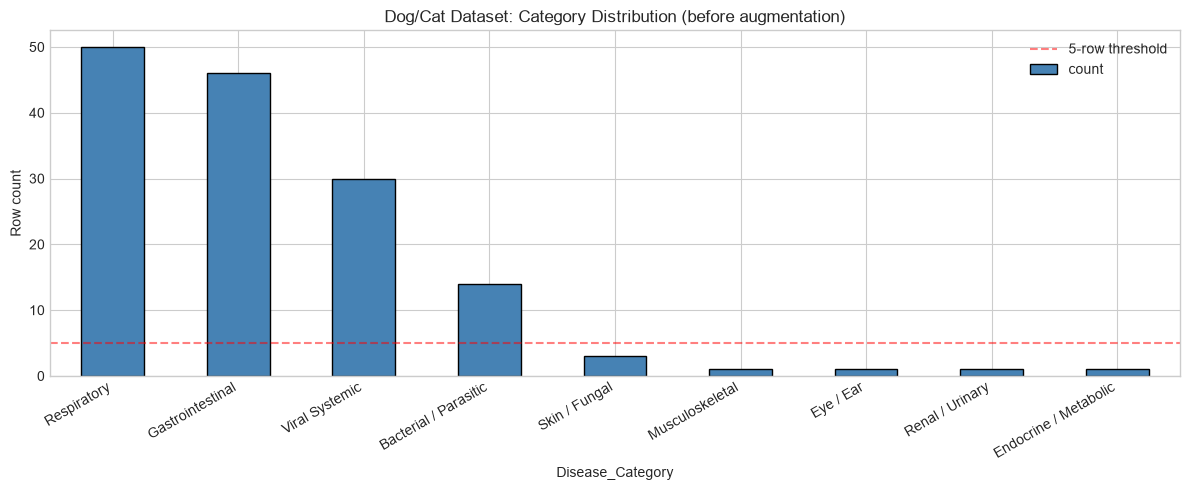

In [6]:
print('=== CATEGORY DISTRIBUTION ===')
cat_counts = df['Disease_Category'].value_counts()
print(cat_counts)
print(f'\nTotal rows: {len(df)}')
print(f'Categories: {df["Disease_Category"].nunique()}')
print(f'\nCategories with < 5 rows (need heavy LLM augmentation):')
print(cat_counts[cat_counts < 5])

fig, ax = plt.subplots(figsize=(12, 5))
cat_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Dog/Cat Dataset: Category Distribution (before augmentation)')
ax.set_ylabel('Row count')
ax.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='5-row threshold')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Also check dog vs cat split per category
print('=== DOG / CAT SPLIT PER CATEGORY ===')
print(pd.crosstab(df['Disease_Category'], df['Animal_Type']))

=== DOG / CAT SPLIT PER CATEGORY ===
Animal_Type            Cat  Dog
Disease_Category               
Bacterial / Parasitic    2   12
Endocrine / Metabolic    1    0
Eye / Ear                1    0
Gastrointestinal        11   35
Musculoskeletal          0    1
Renal / Urinary          1    0
Respiratory             35   15
Skin / Fungal            3    0
Viral Systemic          18   12


## Step 6: Save to Processed

In [8]:
import os
os.makedirs('../data/processed', exist_ok=True)

output_path = '../data/processed/dogs_cats_labeled.csv'
df.to_csv(output_path, index=False)
print(f'Saved: {output_path}')
print(f'Shape: {df.shape}')
print(f'\nColumns saved:')
print(list(df.columns))

Saved: ../data/processed/dogs_cats_labeled.csv
Shape: (147, 23)

Columns saved:
['Animal_Type', 'Breed', 'Age', 'Gender', 'Weight', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Duration', 'Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing', 'Labored_Breathing', 'Lameness', 'Skin_Lesions', 'Nasal_Discharge', 'Eye_Discharge', 'Body_Temperature', 'Heart_Rate', 'Disease_Prediction', 'Disease_Category']


---
## What Comes Next

After running this notebook, `dogs_cats_labeled.csv` is our seed dataset.

The next notebook (`03_llm_augmentation.ipynb`) will:
1. Read this file
2. For each category, generate synthetic rows using an LLM
3. Also generate rows for categories with 0 data (Dental, Trauma/Poisoning)
4. Add urgency labels to all rows
5. Save the final augmented dataset